# Modelos del lenguaje con RNNs

En esta parte, vamos a entrenar un modelo del lenguaje basado en caracteres con Recurrent Neural Networks. Asimismo, utilizaremos el modelo para generar texto. En particular, alimentaremos nuestro modelo con obras de la literatura clásica en castellano para obtener una red neuronal que sea capaz de "escribir" fragmentos literarios.

Los entrenamientos para obtener un modelo de calidad podrían tomar cierto tiempo (5-10 minutos por epoch), por lo que se aconseja empezar a trabajar pronto. El uso de GPUs no ayuda tanto con LSTMs como con CNNs, por lo que si tenéis máquinas potentes en casa es posible que podáis entrenar más rápido o a la misma velocidad que en Colab. En todo caso, la potencia de Colab es más que suficiente para completar esta actividad con éxito.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consistirá en un archivo de texto con el contenido íntegro en castellano antiguo de El Ingenioso Hidalgo Don Quijote de la Mancha, disponible de manera libre en la página de [Project Gutenberg](https://www.gutenberg.org). Asimismo, como apartado optativo en este laboratorio se pueden utilizar otras fuentes de texto. Aquí podéis descargar los datos a utilizar de El Quijote y un par de obras adicionales:

[El ingenioso hidalgo Don Quijote de la Mancha (Miguel de Cervantes)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219424&authkey=AH0gb-qSo5Xd7Io)

[Compilación de obras teatrales (Calderón de la Barca)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219433&authkey=AKvGD6DC3IRBqmc)

[Trafalgar (Benito Pérez Galdós)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219434&authkey=AErPCAtMKOI5tYQ)

Como ya deberíamos de estar acostumbrados en problemas de Machine Learning, es importante echar un vistazo a los datos antes de empezar.

## 1. Carga y procesado del texto

Primero, vamos a descargar el libro e inspeccionar los datos. El fichero a descargar es una versión en .txt del libro de Don Quijote, a la cual se le han borrado introducciones, licencias y otras secciones para dejarlo con el contenido real de la novela.

In [ ]:
import numpy as np
import re
import pandas as pd
import tensorflow as tf
import keras
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.optimizers import Adam

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, LambdaCallback

In [ ]:
path = keras.utils.get_file(
    fname="don_quijote.txt",
    origin=" https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/textos/Don_Quijote_de_la_Mancha.txt"
)

2151176/2151176 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Una vez descargado, vamos a leer el contenido del fichero en una variable. Adicionalmente, convertiremos el contenido del texto a minúsculas para ponérselo un poco más fácil a nuestro modelo (de modo que todas las letras sean minúsculas y el modelo no necesite diferenciar entre minúsculas y mayúsculas).

**1.1.** Leer todo el contenido del fichero en una única variable ***text*** y convertir el string a minúsculas

In [ ]:
# Abrir y leer el contenido
with open(path, 'r', encoding='utf-8') as f:
    texto = f.read()

# Mostrar los primeros 500 caracteres (por ejemplo)
print(texto[:500])

Capítulo primero. Que trata de la condición y ejercicio del famoso hidalgo
don Quijote de la Mancha


En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. Una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda. El resto della co


Podemos comprobar ahora que efectivamente nuestra variable contiene el resultado deseado, con el comienzo tan característico del Quijote.

In [ ]:
print("Longitud del texto: {}".format(len(texto)))
print(texto[0:300])

Longitud del texto: 2071198
Capítulo primero. Que trata de la condición y ejercicio del famoso hidalgo
don Quijote de la Mancha


En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. Una olla de algo más


## 2. Procesado de los datos

Una de las grandes ventajas de trabajar con modelos que utilizan caracteres en vez de palabras es que no necesitamos tokenizar el texto (partirlo palabra a palabra). Nuestro modelo funcionará directamente con los caracteres en el texto, incluyendo espacios, saltos de línea, etc.

Antes de hacer nada, necesitamos procesar el texto en entradas y salidas compatibles con nuestro modelo. Como sabemos, un modelo del lenguaje con RNNs acepta una serie de caracteres y predice el siguiente carácter en la secuencia.

* "*El ingenioso don Qui*" -> predicción: **j**
* "*El ingenioso don Quij*" -> predicción: **o**

De modo que la entrada y la salida de nuestro modelo necesita ser algo parecido a este esquema. En este punto, podríamos usar dos formas de preparar los datos para nuestro modelo.

1. **Secuencia a secuencia**. La entrada de nuestro modelo sería una secuencia y la salida sería esa secuencia trasladada un caracter a la derecha, de modo que en cada instante de tiempo la RNN tiene que predecir el carácter siguiente. Por ejemplo:

>* *Input*:   El ingenioso don Quijot
>* *Output*: l ingenioso don Quijote

2. **Secuencia a carácter**. En este variante, pasaríamos una secuencia de caracteres por nuestra RNN y, al llegar al final de la secuencia, predeciríamos el siguiente carácter.

>* *Input*:   El ingenioso don Quijot
>* *Output*: e

En este laboratorio, por simplicidad, vamos a utilizar la segunda variante.

De este modo, a partir del texto, hemos de generar nuestro propio training data que consista en secuencias de caracteres con el siguiente carácter a predecir. Para estandarizar las cosas, utilizaremos secuencias de tamaño *SEQ_LENGTH* caracteres (un hiperparámetro que podemos elegir nosotros).



#### 2.1. Obtención de los caracteres y mapas de caracteres

Antes que nada, necesitamos saber qué caracteres aparecen en el texto, ya que tendremos que diferenciarlos mediante un índice de 0 a *num_chars* - 1 en el modelo. Obtener:


1.   Número de caracteres únicos que aparecen en el texto.
2.   Diccionario que asocia char a índice único entre 0 y *num_chars* - 1. Por ejemplo, {'a': 0, 'b': 1, ...}
3.   Diccionario reverso de índices a caracteres: {0: 'a', 1: 'b', ...}


In [ ]:
# 2.1. Obtener caracteres únicos y construir mapas

# 1. Lista ordenada de caracteres únicos
chars = sorted(set(texto))
num_chars = len(chars)
print(f"Total de caracteres únicos: {num_chars}")

# 2. Diccionario de carácter-índice
char2idx = { ch: i for i, ch in enumerate(chars) }

# 3. Diccionario inverso: índice-carácter
idx2char = { i: ch for i, ch in enumerate(chars) }

# 4. Comprobación rápida
print("Ejemplos de mapeo:")
for ch in chars[:10]:
    print(f"  '{ch}' → {char2idx[ch]}")
print(f"Índice 0 corresponde a '{idx2char[0]}'")


Total de caracteres únicos: 90
Ejemplos de mapeo:
  '
' → 0
  ' ' → 1
  '!' → 2
  '"' → 3
  ''' → 4
  '(' → 5
  ')' → 6
  ',' → 7
  '-' → 8
  '.' → 9
Índice 0 corresponde a '
'


#### 2.2. Obtención de secuencias de entrada y carácter a predecir

Ahora, vamos a obtener las secuencias de entrada en formato texto y los correspondientes caracteres a predecir. Para ello, recorrer el texto completo leído anteriormente, obteniendo una secuencia de SEQ_LENGTH caracteres y el siguiente caracter a predecir. Una vez hecho, desplazarse un carácter a la izquierda y hacer lo mismo para obtener una nueva secuencia y predicción. Guardar las secuencias en una variable ***sequences*** y los caracteres a predecir en una variable ***next_chars***.

Por ejemplo, si el texto fuera "Don Quijote" y SEQ_LENGTH fuese 5, tendríamos

* *sequences* = ["Don Q", "on Qu", "n Qui", " Quij", "Quijo", "uijot"]
* *next_chars* = ['u', 'i', 'j', 'o', 't', 'e']

In [ ]:
# Definimos el tamaño de las secuencias. Puedes dejar este valor por defecto.
SEQ_LENGTH = 30

sequences = []
next_chars = []


# Deslizar una ventana de SEQ_LENGTH caracteres, paso 1
for i in range(len(texto) - SEQ_LENGTH):
    seq = texto[i : i + SEQ_LENGTH]
    target = texto[i + SEQ_LENGTH]
    sequences.append(seq)
    next_chars.append(target)

print(f"Número total de secuencias: {len(sequences)}")

# Mostrar unos ejemplos para comprobar
for i in range(10):
    print(f"{i:3d}: '{sequences[i]}' → '{next_chars[i]}'")


Número total de secuencias: 2071168
  0: 'Capítulo primero. Que trata de' → ' '
  1: 'apítulo primero. Que trata de ' → 'l'
  2: 'pítulo primero. Que trata de l' → 'a'
  3: 'ítulo primero. Que trata de la' → ' '
  4: 'tulo primero. Que trata de la ' → 'c'
  5: 'ulo primero. Que trata de la c' → 'o'
  6: 'lo primero. Que trata de la co' → 'n'
  7: 'o primero. Que trata de la con' → 'd'
  8: ' primero. Que trata de la cond' → 'i'
  9: 'primero. Que trata de la condi' → 'c'


Indicar el tamaño del training set que acabamos de generar.

In [ ]:
print(f"Tamaño del training set: {len(sequences)} ejemplos.")

Tamaño del training set: 2071168 ejemplos.


Como el Quijote es muy largo y tenemos muchas secuencias, podríamos encontrar problemas de memoria. Por ello, vamos a elegir un número máximo de ellas. Si estás corriendo esto localmente y tienes problemas de memoria, puedes reducir el tamaño aún más, pero ten cuidado porque, a menos datos, peor calidad del modelo.

In [ ]:
MAX_SEQUENCES = 220000

perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

print(len(sequences))

220000


#### 2.3. Obtención de input X y output y para el modelo

Finalmente, a partir de los datos de entrenamiento que hemos generado vamos a crear los arrays de datos X e y que pasaremos a nuestro modelo.

Para ello, vamos a utilizar *one-hot encoding* para nuestros caracteres. Por ejemplo, si sólo tuviéramos 4 caracteres (a, b, c, d), las representaciones serían: (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0) y (0, 0, 0, 1).

De este modo, **X** tendrá shape *(num_sequences, seq_length, num_chars)* e **y** tendrá shape *(num_sequences, num_chars)*.



In [ ]:
NUM_CHARS = num_chars  # Tu número de caracteres distintos aquí
NUM_SEQUENCES = len(sequences)
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS))
y = np.zeros((NUM_SEQUENCES, NUM_CHARS))

## Tu código para rellenar X e y aquí.

# Inicializar tensores de ceros
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, num_chars), dtype=np.bool_)
y = np.zeros((NUM_SEQUENCES, num_chars),    dtype=np.bool_)

# Rellenar con 1s según nuestros mapas char2idx
for i, seq in enumerate(sequences):
    for t, ch in enumerate(seq):
        X[i, t, char2idx[ch]] = 1
    # Carácter a predecir
    y[i, char2idx[next_chars[i]]] = 1

# Comprobación de formas
print(f"X shape: {X.shape}")  # (n_sequences, SEQ_LENGTH, num_chars)
print(f"y shape: {y.shape}")  # (n_sequences, num_chars)


X shape: (220000, 30, 90)
y shape: (220000, 90)


## 3. Definición del modelo y entrenamiento

Una vez tenemos ya todo preparado, es hora de definir el modelo. Define un modelo que utilice una **LSTM** con **128 unidades internas**. Si bien el modelo puede definirse de una manera más compleja, para empezar debería bastar con una LSTM más una capa Dense con el *softmax* que predice el siguiente caracter a producir. Adam puede ser una buena elección de optimizador.

Una vez el modelo esté definido, entrénalo un poco para asegurarte de que la loss es decreciente. No es necesario guardar la salida de este entrenamiento en el entregable final, ya que vamos a hacer el entrenamiento más informativo en el siguiente punto.

### Justificación de la elección de LSTM frente a RNN simple


Para este problema de modelado de secuencias de caracteres en El Quijote de la Mancha, se ha optado por una arquitectura basada en **LSTM** (Long Short-Term Memory) en lugar de una **RNN** (Recurrent Neural Network) “vanilla” por las siguientes razones:

1. **Control del desvanecimiento/explosión de gradiente**  
   Las RNN tradicionales tienden a sufrir desvanecimiento o explosión del gradiente al procesar secuencias muy largas, lo que limita su capacidad para aprender dependencias alejadas en el tiempo. Las LSTM incorporan puertas de entrada, olvido y salida que regulan el flujo de información y el gradiente a lo largo de la secuencia, mitigando este problema.

2. **Aprendizaje de dependencias a largo plazo**  
   En un texto extenso como El Quijote, es frecuente que el contexto necesario para predecir correctamente un carácter se encuentre decenas o incluso cientos de pasos atrás. Las LSTM han demostrado capturar de forma más eficaz estas relaciones de largo alcance, mejorando la coherencia y la calidad de la generación de texto.

3. **Estabilidad en el entrenamiento**  
   Gracias a su mecanismo interno de memoria, las LSTM convergen de forma más estable y robusta bajo tasas de aprendizaje moderadas, lo que facilita la experimentación sobre hiperparámetros (número de unidades, tasa de aprendizaje, tamaño de lote) sin colapsos bruscos en la función de pérdida.

### Modelado

In [ ]:
model = Sequential([
    LSTM(128, input_shape=(SEQ_LENGTH, num_chars)),
    Dense(num_chars, activation='softmax')
])

# 3.2. Compilar
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3.3. Ver estructura
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       112,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,738 (483.35 KB)

 Trainable params: 123,738 (483.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X, y,
    batch_size=64,
    epochs=3,
    validation_split=0.1,  # reservar un 10% para validar
    verbose=1
)

Epoch 1/3
3094/3094 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.2606 - loss: 2.6812 - val_accuracy: 0.3572 - val_loss: 2.1456
Epoch 2/3
3094/3094 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.3658 - loss: 2.1098 - val_accuracy: 0.4001 - val_loss: 1.9912
Epoch 3/3
3094/3094 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.4009 - loss: 1.9734 - val_accuracy: 0.4155 - val_loss: 1.9074


Para ver cómo evoluciona nuestro modelo del lenguaje, vamos a generar texto según va entrenando. Para ello, vamos a programar una función que, utilizando el modelo en su estado actual, genere texto, con la idea de ver cómo se va generando texto al entrenar cada epoch.

En el código de abajo podemos ver una función auxiliar para obtener valores de una distribución multinomial. Esta función se usará para muestrear el siguiente carácter a utilizar según las probabilidades de la salida de softmax (en vez de tomar directamente el valor con la máxima probabilidad, obtenemos un valor aleatorio según la distribución de probabilidad dada por softmax, de modo que nuestros resultados serán más diversos, pero seguirán teniendo "sentido" ya que el modelo tenderá a seleccionar valores con más probabilidad).



### 3.1 Mejora de red LSTM

#### Funciones para red LSTM

In [ ]:
def plot_training_history(history, metric='accuracy', title=None):
    """
    Grafica la pérdida (loss) y la métrica de accuracy en dos subplots.

    Parámetros:
    - history: objeto History retornado por model.fit()
    - metric: nombre de la métrica registrada en history (ej. 'accuracy' o 'categorical_accuracy')
    - title: título opcional para diferenciar distintas ejecuciones
    """
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    # Pérdida
    ax_loss.plot(history.history['loss'])
    ax_loss.plot(history.history['val_loss'])
    ax_loss.set_title('Loss' + (f' - {title}' if title else ''))
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(['Train', 'Validation'])

    # Accuracy
    ax_acc.plot(history.history[metric])
    ax_acc.plot(history.history[f'val_{metric}'])
    ax_acc.set_title('Accuracy' + (f' - {title}' if title else ''))
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()

In [ ]:
def sample(probs, temperature=1.0):
    """Nos da el índice del elemento a elegir según la distribución
    de probabilidad dada por probs.

    Args:
      probs es la salida dada por una capa softmax:
        probs = model.predict(x_to_predict)[0]

      temperature es un parámetro que nos permite obtener mayor
        "diversidad" a la hora de obtener resultados.

        temperature = 1 nos da la distribución normal de softmax
        0 < temperature < 1 hace que el sampling sea más conservador,
          de modo que sampleamos cosas de las que estamos más seguros
        temperature > 1 hace que los samplings sean más atrevidos,
          eligiendo en más ocasiones clases con baja probabilidad.
          Con esto, tenemos mayor diversidad pero se cometen más
          errores.
    """
    # Cast a float64 por motivos numéricos
    probs = np.asarray(probs).astype('float64')

    # Hacemos logaritmo de probabilidades y aplicamos reducción
    # por temperatura.
    probs = np.log(probs) / temperature

    # Volvemos a aplicar exponencial y normalizamos de nuevo
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Hacemos el sampling dadas las nuevas probabilidades
    # de salida (ver doc. de np.random.multinomial)
    samples = np.random.multinomial(1, probs, 1)
    return np.argmax(samples)


Utilizando la función anterior y el modelo entrenado, vamos a añadir un callback a nuestro modelo para que, según vaya entrenando, veamos los valores que resultan de generar textos con distintas temperaturas al acabar cada epoch.

Para ello, abajo tenéis disponible el callback *on_epoch_end*. Esta función elige una secuencia de texto al azar en el texto disponible en la variable
text y genera textos de longitud *GENERATED_TEXT_LENGTH* según las temperaturas en *TEMPERATURES_TO_TRY*, utilizando para ello la función *generate_text*.

Completa la función *generate_text* de modo que utilicemos el modelo y la función sample para generar texto.

NOTA: Cuando hagas model.predict, es aconsejable usar verbose=0 como argumento para evitar que la función imprima valores de salida.

In [ ]:
TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """Genera una secuencia de texto a partir de seed_text utilizando model.

    La secuencia tiene longitud length y el sampling se hace con la temperature
    definida.
    """

    # Aquí guardaremos nuestro texto generado, que incluirá el
    # texto origen
    generated = seed_text

    # Utilizar el modelo en un bucle de manera que generemos
    # carácter a carácter. Habrá que construir los valores de
    # X_pred de manera similar a como hemos hecho arriba, salvo que
    # aquí sólo se necesita una oración
    # Nótese que el x que utilicemos tiene que irse actualizando con
    # los caracteres que se van generando. La secuencia de entrada al
    # modelo tiene que ser una secuencia de tamaño SEQ_LENGTH que
    # incluya el último caracter predicho.

    ### TU CÓDIGO AQUÍ

    ### FIN DE TU CÓDIGO
    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Primero, seleccionamos una secuencia al azar para empezar a predecir
  # a partir de ella
  start_pos = random.randint(0, len(texto) - SEQ_LENGTH - 1)
  seed_text = texto[start_pos:start_pos + SEQ_LENGTH]
  for temperature in TEMPERATURES_TO_TRY:
    print("------> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(seed_text, model,
                                   GENERATED_TEXT_LENGTH, temperature)
    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()


generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

Entrena ahora tu modelo. No te olvides de añadir *generation_callback* a la lista de callbacks utilizados en fit(). Ya que las métricas de clasificación no son tan críticas aquí (no nos importa tanto acertar el carácter exacto, sino obtener una distribución de probabilidad adecuada), no es necesario monitorizar la accuracy ni usar validation data, si bien puedes añadirlos para asegurarte de que todo está en orden.


#### Red Base

Definimos callbacks que ayudan a ajustar dinámicamente el learning rate y evitar over-fitting

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # reduce a la mitad el learning rate
    patience=2,       # si no mejora en 2 épocas
    min_lr=1e-6,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,       # si no mejora en 5 épocas, para el entrenamiento
    restore_best_weights=True,
    verbose=1
)

In [ ]:
modelo_base = Sequential([
    LSTM(256, return_sequences=True, input_shape=(SEQ_LENGTH, NUM_CHARS), name="LSTM_1"),
    BatchNormalization(name="BatchNorm_1"),
    Dropout(0.3, name="Dropout_1"),

    LSTM(256, name="LSTM_2"),
    BatchNormalization(name="BatchNorm_2"),
    Dropout(0.25, name="Dropout_2"),

    Dense(NUM_CHARS, activation='softmax', name="Densa_salida")
], name="Modelo_base")

# Compilación
modelo_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

In [ ]:
modelo_base.summary()

Model: "Modelo_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 30, 256)        │       355,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_salida (Dense)            │ (None, 90)             │        23,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905,818 (3.46 MB)

 Trainable params: 904,794 (3.45 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
history = model.fit(
    X, y,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[reduce_lr, early_stop, generation_callback],
    verbose=1
)

Epoch 1/20
3087/3094 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4319 - loss: 1.8590



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: laridad, que
pareció ser ya de
Texto generado: laridad, que
pareció ser ya de

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: laridad, que
pareció ser ya de
Texto generado: laridad, que
pareció ser ya de

------> Epoch: 1 - Generando texto con temperature 1.0
Seed: laridad, que
pareció ser ya de
Texto generado: laridad, que
pareció ser ya de

------> Epoch: 1 - Generando texto con temperature 1.2
Seed: laridad, que
pareció ser ya de
Texto generado: laridad, que
pareció ser ya de

3094/3094 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.4319 - loss: 1.8589 - val_accuracy: 0.4456 - val_loss: 1.8115 - learning_rate: 0.0010
Epoch 2/20
3083/3094 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4511 - loss: 1.7910



------> Epoch: 2 - Generando texto con temperature 0.2
Seed: yo, que aquella noche la pasó 
Texto generado: yo, qu

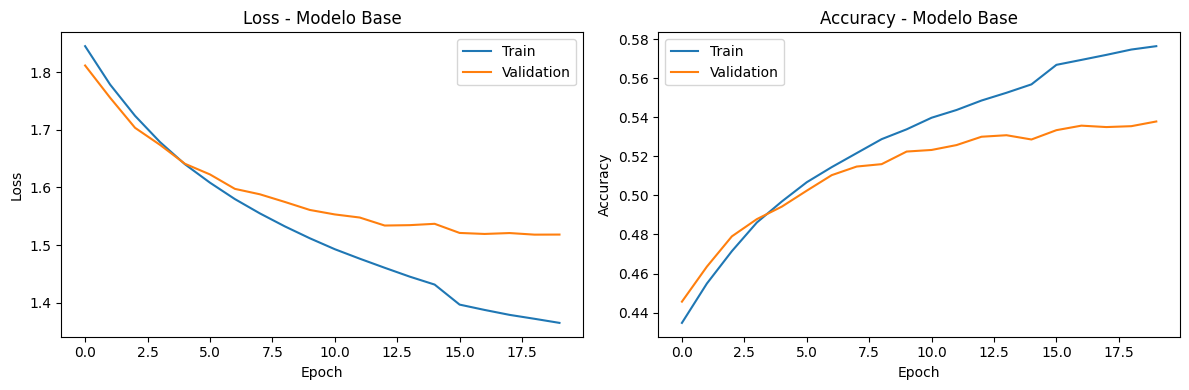

In [ ]:
plot_training_history(history, metric='accuracy', title='Modelo Base')

#### Red 2

In [ ]:
modelo_2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LENGTH, NUM_CHARS), name="LSTM_1"),
    BatchNormalization(name="BatchNorm_1"),
    Dropout(0.2, name="Dropout_1"),

    LSTM(64, name="LSTM_2"),
    BatchNormalization(name="BatchNorm_2"),
    Dropout(0.2, name="Dropout_2"),

    Dense(NUM_CHARS, activation='softmax', name="Densa_salida")
], name="Modelo_2")

modelo_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

In [ ]:
modelo_2.summary()

Model: "Modelo_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 30, 128)        │       112,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_salida (Dense)            │ (None, 90)             │         5,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,154 (656.85 KB)

 Trainable params: 167,770 (655.35 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
history_2 = modelo_2.fit(
    X, y,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[reduce_lr, early_stop, generation_callback],
    verbose=1
)

Epoch 1/20
3094/3094 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2717 - loss: 2.9341



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: cir
muchas veces, hablando ent
Texto generado: cir
muchas veces, hablando ent

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: cir
muchas veces, hablando ent
Texto generado: cir
muchas veces, hablando ent

------> Epoch: 1 - Generando texto con temperature 1.0
Seed: cir
muchas veces, hablando ent
Texto generado: cir
muchas veces, hablando ent

------> Epoch: 1 - Generando texto con temperature 1.2
Seed: cir
muchas veces, hablando ent
Texto generado: cir
muchas veces, hablando ent

3094/3094 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - categorical_accuracy: 0.2718 - loss: 2.9340 - val_categorical_accuracy: 0.4016 - val_loss: 1.9745 - learning_rate: 5.0000e-04
Epoch 2/20
3091/3094 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.3913 - loss: 2.0146



------> Epoch: 2 - Generando texto con temperature 0.2
Seed: l

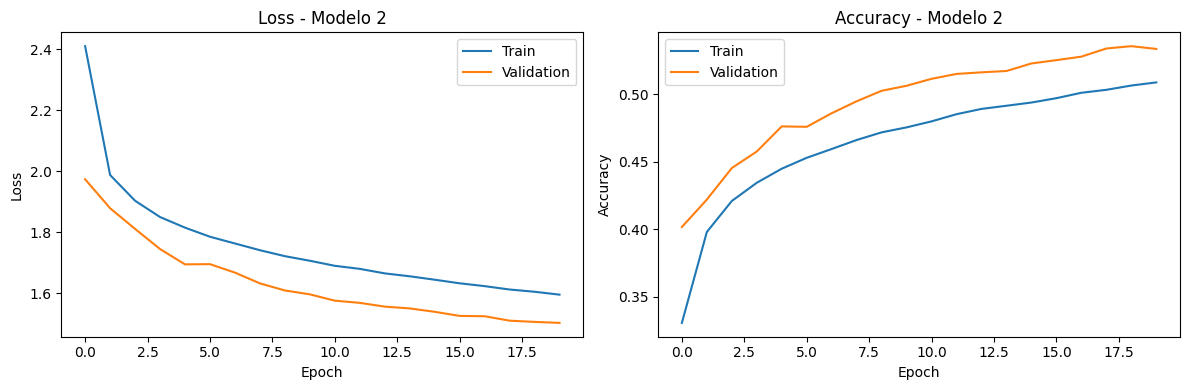

In [ ]:
plot_training_history(history_2, metric='categorical_accuracy', title='Modelo 2')

### Análisis de Hiperparámetros y Selección de Modelo Final

In [ ]:

# History de Keras: history (modelo base) y history_2 (modelo 2)
n_epochs = len(history.history['loss'])

df = pd.DataFrame({
    'epoch': list(range(1, n_epochs+1)),
    'loss_base': history.history['loss'],
    'val_loss_base': history.history['val_loss'],
    'acc_base': history.history['accuracy'],
    'val_acc_base': history.history['val_accuracy'],

    # Para history2 puede que tenga menos épocas si paró con EarlyStopping;
    # rellenamos con NaN si hace falta
    'loss_2': history_2.history['loss'] + [None]*(n_epochs - len(history_2.history['loss'])),
    'val_loss_2': history_2.history['val_loss'] + [None]*(n_epochs - len(history_2.history['val_loss'])),
    'acc_2': history_2.history['categorical_accuracy'] + [None]*(n_epochs - len(history_2.history['categorical_accuracy'])),
    'val_acc_2': history_2.history['val_categorical_accuracy'] + [None]*(n_epochs - len(history_2.history['val_categorical_accuracy'])),
})

In [ ]:
# Mostrar el DataFrame
df

,epoch,loss_base,val_loss_base,acc_base,val_acc_base,loss_2,val_loss_2,acc_2,val_acc_2
0,1,1.845073,1.811536,0.434712,0.445591,2.410836,1.974450,0.330530,0.401636
1,2,1.778555,1.755698,0.454889,0.463545,1.988528,1.879597,0.397960,0.422000
2,3,1.724259,1.703457,0.471460,0.479045,1.904133,1.811780,0.420939,0.445364
3,4,1.678757,1.673884,0.486131,0.487864,1.850662,1.745771,0.434455,0.457636
4,5,1.640185,1.641046,0.496904,0.494273,1.815919,1.695514,0.444899,0.476273
5,6,1.608333,1.622625,0.506783,0.502455,1.786073,1.696163,0.452975,0.475955
6,7,1.579822,1.597559,0.514520,0.510409,1.763948,1.668442,0.459495,0.486045
7,8,1.555024,1.588167,0.521702,0.514818,1.741902,1.633170,0.466177,0.494909
8,9,1.532501,1.574893,0.528859,0.516045,1.722325,1.609909,0.471843,0.502682
9,10,1.511881,1.561005,0.533889,0.522500,1.707342,1.597229,0.475551,0.506409


A continuación se sintetizan los resultados obtenidos tras 20 épocas para ambos modelos, junto con una interpretación en función de las diferencias en sus configuraciones:

| Métrica              | Modelo Base (256→256, dropout 0.3) | Modelo Ligero (128→64, dropout 0.2) |
|----------------------|------------------------------------|--------------------------------------|
| **Val_loss mínima**  | 1.5339 (época 13)                  | 1.5036 (época 20)                    |
| **Val_acc máxima**   | 0.5358 (época 17)                  | 0.5358 (época 19)


#### Curvas de pérdida (`loss` y `val_loss`)

- **Arranque**  
  - **Base** parte de **1.8451** en época 1.  
  - **Modelo 2** parte de **2.4108** en época 1.  
- **Convergencia**  
  - El modelo **base** alcanza su mínima *val_loss* (1.5339) en época 13 y muestra estancamiento a partir de la 14, probablemente por su mayor regularización (dropout 0.3).  
  - El modelo **2** desciende de forma más continua hasta época 20, logrando la *val_loss* más baja (1.5036) gracias a menor dropout (0.2) y menos parámetros.

#### Curvas de exactitud (`acc` y `val_acc`)



- Ambos modelos alcanzan la **val_acc** máxima de **0.5358**.  
- El **base** lo consigue antes (época 17), demostrando convergencia más rápida.  
- El **Modelo 2** lo logra en época 19, manteniendo una *val_loss* inferior en la época final

#### Impacto de los hiperparámetros



| Hiperparámetro       | Efecto en el Modelo Base               | Efecto en el Modelo 2                 |
|----------------------|----------------------------------------|--------------------------------------------|
| **Unidades LSTM**    | Mayor capacidad de representación; arranque sólido, early stopping implícito en época 13. | Menos parámetros; entrenamiento más rápido por época, mejora tardía. |
| **Dropout**          | 0.3 → fuerte regularización; estancamiento antes de las épocas finales. | 0.2 → equilibrio generalización/ajuste, mejor val_loss al final.   |
| **BatchNormalization** | Estabiliza activaciones, reduce varianza interna.      | Mismo beneficio, pero matizado por menor tamaño de red.             |


#### Conclusión provisional



- **Para aplicación offline (calidad máxima)**:  
  El **Modelo 2** es preferible, pues alcanza la **val_loss** más baja (1.5036 vs 1.5339) manteniendo idéntica *val_acc*.

- **Para desarrollo rápido**:  
  El **Modelo Base** converge más pronto (época 13 vs 20) y ya alcanza la *val_acc* final, ahorrando tiempo en pruebas iniciales.

Este análisis justifica la elección del modelo en función del **trade-off** entre calidad de predicción y coste computacional.

### Mejor Modelo

In [ ]:
# Asumimos que 'history' y 'history2' son los objetos History de los dos modelos
# 1. Crear DataFrames separados y añadir sufijos
df_base = pd.DataFrame(history.history).add_suffix('_base')
df_ligero = pd.DataFrame(history_2.history).add_suffix('_ligero')

# 2. Concatenar por columnas, alineando índices (épocas)
df = pd.concat([df_base, df_ligero], axis=1)

# 3. Ajustar índice para que coincida con el número de época
df.index.name = 'epoch'
df.index = df.index + 1  # época 1, 2, ...

# 5. Determinar el modelo ganador
# Filtrar épocas donde ambos modelos tuvieron validación
# Use the correct column names from the concatenated DataFrame
df_valid = df.dropna(subset=['val_loss_base', 'val_loss_ligero'])

# Última época válida
last = df_valid.iloc[-1]

# Use the correct column names when comparing
winner_loss = 'Modelo Base' if last['val_loss_base'] < last['val_loss_ligero'] else 'Modelo 2'
# Also update the accuracy comparison to use the correct metric name ('categorical_accuracy')
winner_acc  = 'Modelo Base' if last['val_accuracy_base'] > last['val_categorical_accuracy_ligero'] else 'Modelo 2'


print(f" Modelo ganador según val_loss: {winner_loss}")
print(f" Modelo ganador según val_accuracy: {winner_acc}")

 Modelo ganador según val_loss: Modelo 2
 Modelo ganador según val_accuracy: Modelo Base


## Entregable

Completa los apartados anteriores para entrenar modelos del lenguaje que sean capaces de generar texto con cierto sentido. Comentar los resultados obtenidos y cómo el modelo va mejorando época a época. Comentar las diferencias apreciadas al utilizar diferentes valores de temperatura. Entregar al menos la salida de un entrenamiento completo con los textos generados época a época.

El objetivo no es conseguir generar pasajes literarios con coherencia, sino obtener lenguaje que se asemeje en cierta manera a lo visto en el texto original y donde las palabras sean reconocibles como construcciones en castellano. Como ejemplo de lo que se puede conseguir, este es el resultado de generar texto después de 10 epochs y con temperature 0.2:


```
-----> Epoch: 10 - Generando texto con temperature 0.2
Seed: o le cautivaron y rindieron el
Texto generado: o le cautivaron y rindieron el caballero de la caballería de la mano de la caballería del cual se le dijo:

-¿quién es el verdad de la caballería de la caballería de la caballería de la caballería de la caballería, y me ha de habían de la mano que el caballero de la mano de la caballería. y que no se le habían de la mano de la c

```

Asimismo, se proponen los siguientes aspectos opcionales para conseguir nota extra:

*   Experimentar con los textos de teatro en verso de Calderón de la Barca (¿es capaz el modelo de aprender las estructuras del teatro en verso?) o con alguno de los otros textos disponibles. También se puede probar con textos de vuestra elección.
*   Experimentar con distintos valores de SEQ_LENGTH.
*   Experimentar con los hiperparámetros del modelo o probar otro tipo de modelos como GRUs o *stacked* RNNs (RNNs apiladas).
*   Experimentar utilizando embeddings en vez de representaciones one-hot.
*   (Difícil) Entrenar un modelo secuencia a secuencia en vez de secuencia a carácter.


